In [161]:
import pandas as pd
import numpy as np

In [162]:
df = pd.read_csv("test.csv", encoding="latin1")

In [163]:
df.head()

,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,f87dea47db,Last session of the day http://twitpic.com/67ezh,neutral,morning,0-20,Afghanistan,38928346.0,652860.0,60.0
1,96d74cb729,Shanghai is also really exciting (precisely -...,positive,noon,21-30,Albania,2877797.0,27400.0,105.0
2,eee518ae67,"Recession hit Veronique Branquinho, she has to...",negative,night,31-45,Algeria,43851044.0,2381740.0,18.0
3,01082688c6,happy bday!,positive,morning,46-60,Andorra,77265.0,470.0,164.0
4,33987a8ee5,http://twitpic.com/4w75p - I like it!!,positive,noon,60-70,Angola,32866272.0,1246700.0,26.0


In [164]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4815 entries, 0 to 4814
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   textID            3534 non-null   object 
 1   text              3534 non-null   object 
 2   sentiment         3534 non-null   object 
 3   Time of Tweet     3534 non-null   object 
 4   Age of User       3534 non-null   object 
 5   Country           3534 non-null   object 
 6   Population -2020  3534 non-null   float64
 7   Land Area (Km²)   3534 non-null   float64
 8   Density (P/Km²)   3534 non-null   float64
dtypes: float64(3), object(6)
memory usage: 338.7+ KB


In [30]:
df.describe()

,Population -2020,Land Area (Km²),Density (P/Km²)
count,3.534000e+03,3.534000e+03,3534.000000
mean,3.941891e+07,6.722499e+05,348.894171
std,1.468757e+08,1.839134e+06,1967.012367
min,8.010000e+02,0.000000e+00,2.000000
25%,1.968001e+06,2.281000e+04,35.000000
50%,8.696453e+06,1.127600e+05,87.000000
75%,2.843594e+07,5.279700e+05,214.000000
max,1.439324e+09,1.637687e+07,26337.000000


In [31]:
df.shape

(4815, 9)

In [32]:
df.columns

Index(['textID', 'text', 'sentiment', 'Time of Tweet', 'Age of User',
       'Country', 'Population -2020', 'Land Area (Km²)', 'Density (P/Km²)'],
      dtype='object')

In [104]:
df.isnull().sum()

textID              1281
text                1281
sentiment           1281
Time of Tweet       1281
Age of User         1281
Country             1281
Population -2020    1281
Land Area (Km²)     1281
Density (P/Km²)     1281
dtype: int64

In [105]:
df['Country'].value_counts()

Country
Afghanistan      20
Ecuador          20
China            20
Colombia         20
Comoros          20
                 ..
Guinea-Bissau    16
Guinea           16
Guatemala        16
Grenada          16
Greece           16
Name: count, Length: 195, dtype: int64

In [165]:
df['sentiment'].value_counts(normalize= True) * 100

sentiment
neutral     40.464063
positive    31.211092
negative    28.324844
Name: proportion, dtype: float64

In [107]:
df[['text','sentiment']].head(10)


,text,sentiment
0,Last session of the day http://twitpic.com/67ezh,neutral
1,Shanghai is also really exciting (precisely -...,positive
2,"Recession hit Veronique Branquinho, she has to...",negative
3,happy bday!,positive
4,http://twitpic.com/4w75p - I like it!!,positive
5,that`s great!! weee!! visitors!,positive
6,I THINK EVERYONE HATES ME ON HERE lol,negative
7,"soooooo wish i could, but im in school and my...",negative
8,and within a short time of the last clue all ...,neutral
9,What did you get? My day is alright.. haven`...,neutral


In [166]:
df['sentiment'].isnull().sum()

1281

In [109]:
df['text'].isnull().sum()


1281

In [167]:
df = df.dropna(subset=['text','sentiment'])

In [168]:
df[['text','sentiment']].isnull().sum()

text         0
sentiment    0
dtype: int64

In [112]:
df.shape

(3534, 9)

In [113]:
df['sentiment'].isnull().sum()

0

In [43]:
df['text'].isnull().sum()

0

In [44]:
df['Country'].isnull().sum()

0

In [45]:
df.isnull().sum()

textID              0
text                0
sentiment           0
Time of Tweet       0
Age of User         0
Country             0
Population -2020    0
Land Area (Km²)     0
Density (P/Km²)     0
dtype: int64

In [46]:
df.duplicated().sum()


0

In [114]:
df['text'].duplicated().sum()


0

In [169]:
# Lets understand Sentiment analysis
df['sentiment'].value_counts(normalize= True) * 100

sentiment
neutral     40.464063
positive    31.211092
negative    28.324844
Name: proportion, dtype: float64

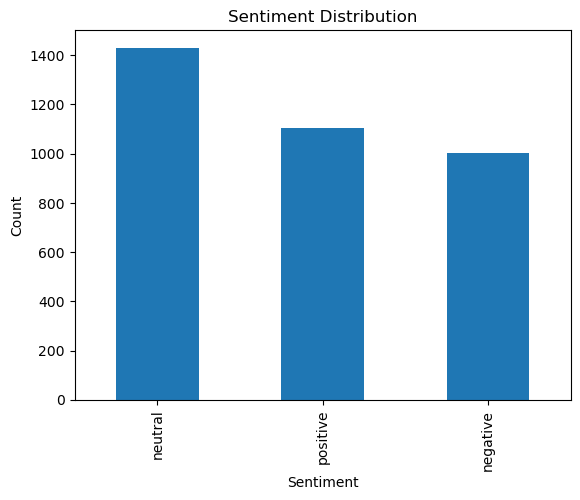

In [170]:
df['sentiment'].value_counts().plot(kind ='bar')
import matplotlib.pyplot as plt
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title("Sentiment Distribution")
plt.show()


In [171]:
# LowerCasing
df['text'].head()

0    Last session of the day  http://twitpic.com/67ezh
1     Shanghai is also really exciting (precisely -...
2    Recession hit Veronique Branquinho, she has to...
3                                          happy bday!
4               http://twitpic.com/4w75p - I like it!!
Name: text, dtype: object

In [172]:
df['cleaned_text'] = df['text'].str.lower()

In [173]:
df[['text','cleaned_text']].head(10)

,text,cleaned_text
0,Last session of the day http://twitpic.com/67ezh,last session of the day http://twitpic.com/67ezh
1,Shanghai is also really exciting (precisely -...,shanghai is also really exciting (precisely -...
2,"Recession hit Veronique Branquinho, she has to...","recession hit veronique branquinho, she has to..."
3,happy bday!,happy bday!
4,http://twitpic.com/4w75p - I like it!!,http://twitpic.com/4w75p - i like it!!
5,that`s great!! weee!! visitors!,that`s great!! weee!! visitors!
6,I THINK EVERYONE HATES ME ON HERE lol,i think everyone hates me on here lol
7,"soooooo wish i could, but im in school and my...","soooooo wish i could, but im in school and my..."
8,and within a short time of the last clue all ...,and within a short time of the last clue all ...
9,What did you get? My day is alright.. haven`...,what did you get? my day is alright.. haven`...


In [174]:
# Remove URL
df['cleaned_text'] = df['cleaned_text'].str.replace(
    r"http\S+|www\S+",
    "",
    regex= True
)
    

In [175]:
df[['text','cleaned_text']].head(10)


,text,cleaned_text
0,Last session of the day http://twitpic.com/67ezh,last session of the day
1,Shanghai is also really exciting (precisely -...,shanghai is also really exciting (precisely -...
2,"Recession hit Veronique Branquinho, she has to...","recession hit veronique branquinho, she has to..."
3,happy bday!,happy bday!
4,http://twitpic.com/4w75p - I like it!!,- i like it!!
5,that`s great!! weee!! visitors!,that`s great!! weee!! visitors!
6,I THINK EVERYONE HATES ME ON HERE lol,i think everyone hates me on here lol
7,"soooooo wish i could, but im in school and my...","soooooo wish i could, but im in school and my..."
8,and within a short time of the last clue all ...,and within a short time of the last clue all ...
9,What did you get? My day is alright.. haven`...,what did you get? my day is alright.. haven`...


In [176]:
# Remove  mention @
df['cleaned_text'] = df['cleaned_text'].str.replace(r"@\w+","",regex= True)

In [177]:
df[['text','cleaned_text']].head(20)

,text,cleaned_text
0,Last session of the day http://twitpic.com/67ezh,last session of the day
1,Shanghai is also really exciting (precisely -...,shanghai is also really exciting (precisely -...
2,"Recession hit Veronique Branquinho, she has to...","recession hit veronique branquinho, she has to..."
3,happy bday!,happy bday!
4,http://twitpic.com/4w75p - I like it!!,- i like it!!
5,that`s great!! weee!! visitors!,that`s great!! weee!! visitors!
6,I THINK EVERYONE HATES ME ON HERE lol,i think everyone hates me on here lol
7,"soooooo wish i could, but im in school and my...","soooooo wish i could, but im in school and my..."
8,and within a short time of the last clue all ...,and within a short time of the last clue all ...
9,What did you get? My day is alright.. haven`...,what did you get? my day is alright.. haven`...


In [178]:
# Now lets remove special character
df['cleaned_text'] = df['cleaned_text'].str.replace(r"[^a-z0-9\s]","",regex= True)

In [179]:
df[['text','cleaned_text']].head(20)

,text,cleaned_text
0,Last session of the day http://twitpic.com/67ezh,last session of the day
1,Shanghai is also really exciting (precisely -...,shanghai is also really exciting precisely s...
2,"Recession hit Veronique Branquinho, she has to...",recession hit veronique branquinho she has to ...
3,happy bday!,happy bday
4,http://twitpic.com/4w75p - I like it!!,i like it
5,that`s great!! weee!! visitors!,thats great weee visitors
6,I THINK EVERYONE HATES ME ON HERE lol,i think everyone hates me on here lol
7,"soooooo wish i could, but im in school and my...",soooooo wish i could but im in school and mys...
8,and within a short time of the last clue all ...,and within a short time of the last clue all ...
9,What did you get? My day is alright.. haven`...,what did you get my day is alright havent do...


In [180]:
# Remove extra spaces
df['cleaned_text'] = df['cleaned_text'].str.replace(r"\s+"," ",regex= True).str.strip()

In [181]:
df[['text','cleaned_text']].head(20)

,text,cleaned_text
0,Last session of the day http://twitpic.com/67ezh,last session of the day
1,Shanghai is also really exciting (precisely -...,shanghai is also really exciting precisely sky...
2,"Recession hit Veronique Branquinho, she has to...",recession hit veronique branquinho she has to ...
3,happy bday!,happy bday
4,http://twitpic.com/4w75p - I like it!!,i like it
5,that`s great!! weee!! visitors!,thats great weee visitors
6,I THINK EVERYONE HATES ME ON HERE lol,i think everyone hates me on here lol
7,"soooooo wish i could, but im in school and my...",soooooo wish i could but im in school and mysp...
8,and within a short time of the last clue all ...,and within a short time of the last clue all o...
9,What did you get? My day is alright.. haven`...,what did you get my day is alright havent done...


In [83]:
# Now lets do Tokenization


In [182]:
df['tokens'] = df['cleaned_text'].str.split()

In [183]:
df[['cleaned_text','tokens']].head(10)


,cleaned_text,tokens
0,last session of the day,"[last, session, of, the, day]"
1,shanghai is also really exciting precisely sky...,"[shanghai, is, also, really, exciting, precise..."
2,recession hit veronique branquinho she has to ...,"[recession, hit, veronique, branquinho, she, h..."
3,happy bday,"[happy, bday]"
4,i like it,"[i, like, it]"
5,thats great weee visitors,"[thats, great, weee, visitors]"
6,i think everyone hates me on here lol,"[i, think, everyone, hates, me, on, here, lol]"
7,soooooo wish i could but im in school and mysp...,"[soooooo, wish, i, could, but, im, in, school,..."
8,and within a short time of the last clue all o...,"[and, within, a, short, time, of, the, last, c..."
9,what did you get my day is alright havent done...,"[what, did, you, get, my, day, is, alright, ha..."


In [184]:
import nltk

In [185]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/pramod/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [186]:
from nltk.corpus import stopwords

In [187]:
stop_words = set(stopwords.words('english'))

In [189]:
stop_words.discard('not')

In [190]:
stop_words.discard('no')

In [191]:
stop_words.discard('nor')

In [192]:
df['tokens'] = df['tokens'].apply(
    lambda words:[word for word in words if word not in stop_words]
)


In [193]:
df[["cleaned_text", "tokens"]].head(10)

,cleaned_text,tokens
0,last session of the day,"[last, session, day]"
1,shanghai is also really exciting precisely sky...,"[shanghai, also, really, exciting, precisely, ..."
2,recession hit veronique branquinho she has to ...,"[recession, hit, veronique, branquinho, quit, ..."
3,happy bday,"[happy, bday]"
4,i like it,[like]
5,thats great weee visitors,"[thats, great, weee, visitors]"
6,i think everyone hates me on here lol,"[think, everyone, hates, lol]"
7,soooooo wish i could but im in school and mysp...,"[soooooo, wish, could, im, school, myspace, co..."
8,and within a short time of the last clue all o...,"[within, short, time, last, clue]"
9,what did you get my day is alright havent done...,"[get, day, alright, havent, done, anything, ye..."


In [140]:
# Lemmatization

In [194]:
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to /Users/pramod/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/pramod/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [195]:
from nltk.stem import WordNetLemmatizer

In [196]:
lemmatizer = WordNetLemmatizer()

In [197]:
df['tokens'] = df['tokens'].apply(
    lambda words:[lemmatizer.lemmatize(word) for word in words])

In [198]:
df[["cleaned_text", "tokens"]].head(10)

,cleaned_text,tokens
0,last session of the day,"[last, session, day]"
1,shanghai is also really exciting precisely sky...,"[shanghai, also, really, exciting, precisely, ..."
2,recession hit veronique branquinho she has to ...,"[recession, hit, veronique, branquinho, quit, ..."
3,happy bday,"[happy, bday]"
4,i like it,[like]
5,thats great weee visitors,"[thats, great, weee, visitor]"
6,i think everyone hates me on here lol,"[think, everyone, hate, lol]"
7,soooooo wish i could but im in school and mysp...,"[soooooo, wish, could, im, school, myspace, co..."
8,and within a short time of the last clue all o...,"[within, short, time, last, clue]"
9,what did you get my day is alright havent done...,"[get, day, alright, havent, done, anything, ye..."


In [201]:
df['final_text'] = df['tokens'].apply(lambda words:" ".join(words))

In [202]:
df[["tokens", "final_text"]].head(10)

,tokens,final_text
0,"[last, session, day]",last session day
1,"[shanghai, also, really, exciting, precisely, ...",shanghai also really exciting precisely skyscr...
2,"[recession, hit, veronique, branquinho, quit, ...",recession hit veronique branquinho quit compan...
3,"[happy, bday]",happy bday
4,[like],like
5,"[thats, great, weee, visitor]",thats great weee visitor
6,"[think, everyone, hate, lol]",think everyone hate lol
7,"[soooooo, wish, could, im, school, myspace, co...",soooooo wish could im school myspace completel...
8,"[within, short, time, last, clue]",within short time last clue
9,"[get, day, alright, havent, done, anything, ye...",get day alright havent done anything yet leavi...


In [203]:
df.head(10)

,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²),cleaned_text,tokens,final_text
0,f87dea47db,Last session of the day http://twitpic.com/67ezh,neutral,morning,0-20,Afghanistan,38928346.0,652860.0,60.0,last session of the day,"[last, session, day]",last session day
1,96d74cb729,Shanghai is also really exciting (precisely -...,positive,noon,21-30,Albania,2877797.0,27400.0,105.0,shanghai is also really exciting precisely sky...,"[shanghai, also, really, exciting, precisely, ...",shanghai also really exciting precisely skyscr...
2,eee518ae67,"Recession hit Veronique Branquinho, she has to...",negative,night,31-45,Algeria,43851044.0,2381740.0,18.0,recession hit veronique branquinho she has to ...,"[recession, hit, veronique, branquinho, quit, ...",recession hit veronique branquinho quit compan...
3,01082688c6,happy bday!,positive,morning,46-60,Andorra,77265.0,470.0,164.0,happy bday,"[happy, bday]",happy bday
4,33987a8ee5,http://twitpic.com/4w75p - I like it!!,positive,noon,60-70,Angola,32866272.0,1246700.0,26.0,i like it,[like],like
5,726e501993,that`s great!! weee!! visitors!,positive,night,70-100,Antigua and Barbuda,97929.0,440.0,223.0,thats great weee visitors,"[thats, great, weee, visitor]",thats great weee visitor
6,261932614e,I THINK EVERYONE HATES ME ON HERE lol,negative,morning,0-20,Argentina,45195774.0,2736690.0,17.0,i think everyone hates me on here lol,"[think, everyone, hate, lol]",think everyone hate lol
7,afa11da83f,"soooooo wish i could, but im in school and my...",negative,noon,21-30,Armenia,2963243.0,28470.0,104.0,soooooo wish i could but im in school and mysp...,"[soooooo, wish, could, im, school, myspace, co...",soooooo wish could im school myspace completel...
8,e64208b4ef,and within a short time of the last clue all ...,neutral,night,31-45,Australia,25499884.0,7682300.0,3.0,and within a short time of the last clue all o...,"[within, short, time, last, clue]",within short time last clue
9,37bcad24ca,What did you get? My day is alright.. haven`...,neutral,morning,46-60,Austria,9006398.0,82400.0,109.0,what did you get my day is alright havent done...,"[get, day, alright, havent, done, anything, ye...",get day alright havent done anything yet leavi...


In [150]:
# Let's do train-test split here

In [204]:
X = df['final_text']
y = df['sentiment']

In [205]:
from sklearn.model_selection import train_test_split

In [206]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size = 0.2,random_state = 42,stratify = y)

In [207]:
print(X_train.shape)
print(X_test.shape)

(2827,)
(707,)


In [208]:
print(y_train.shape)
print(y_test.shape)

(2827,)
(707,)


In [209]:
# TF-IDF vectorization.
from sklearn.feature_extraction.text import TfidfVectorizer

In [258]:
tfidf = TfidfVectorizer(
    max_features = 5000,
    min_df = 2,
    max_df = 0.95)

In [259]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [260]:
X_test_tfidf = tfidf.transform(X_test)

In [261]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(2827, 1959)
(707, 1959)


In [262]:
# Apply Logistic regression as well
from sklearn.linear_model import LogisticRegression

In [263]:
model = LogisticRegression(max_iter=1000,class_weight='balanced')

model.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [264]:
y_pred = model.predict(X_test_tfidf)

In [265]:
y_pred[:10]

array(['positive', 'positive', 'neutral', 'negative', 'neutral',
       'positive', 'negative', 'positive', 'neutral', 'positive'],
      dtype=object)

In [252]:
print("Predicted:", y_pred[:10])
print("Actual   :", y_test.values[:10])

Predicted: ['positive' 'positive' 'neutral' 'negative' 'negative' 'positive'
 'negative' 'positive' 'neutral' 'positive']
Actual   : ['neutral' 'positive' 'neutral' 'negative' 'negative' 'positive'
 'negative' 'positive' 'neutral' 'positive']


In [266]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.6364922206506365


In [267]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.63      0.63      0.63       200
     neutral       0.59      0.61      0.60       286
    positive       0.72      0.67      0.69       221

    accuracy                           0.64       707
   macro avg       0.64      0.64      0.64       707
weighted avg       0.64      0.64      0.64       707



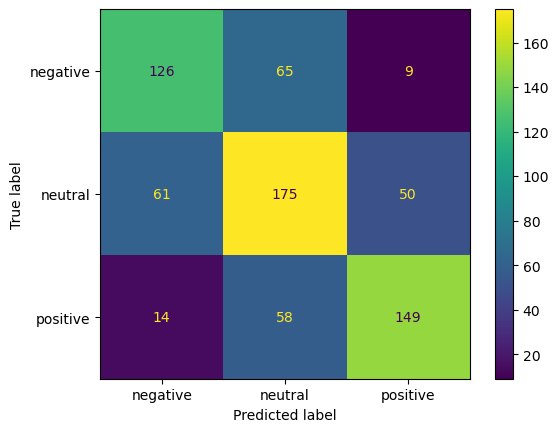

In [268]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.show()

In [255]:
# Lets try with another model

In [269]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

In [270]:
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.594059405940594


In [271]:
#Now lets try with SVM


In [272]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(class_weight="balanced")

svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.6082036775106082
